In [1]:
import os
import time
import re

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import sparse

import scanpy as sc
import anndata as ad

import pandas as pd
import numpy as np

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import preprocess as pp
from scLEMBAS import io

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [3]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

Load in the raw counts data:

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

Normalize and get HVGs:

In [5]:
%%time
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')


CPU times: user 56.1 s, sys: 1.3 s, total: 57.4 s
Wall time: 57.4 s


Get the TF activity:

Some [reasoning](https://chatgpt.com/c/686373d4-20dc-800b-b5f8-1bfdc646e718) for using all genes rather than HVGs.

In [6]:
%%time

n_batches = 12 #20
batch_size = int(np.round(adata.shape[0]/n_batches))
kwargs = {'args' : {'wsum' : {'times': int(1), # since we don't use the p-vals
                              'batch_size': batch_size},
                       'ulm' : {'batch_size': batch_size}, 
                        'mlm': {'batch_size': batch_size}
                       }, 
         'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['wsum_estimate', 'ulm_estimate', 'mlm_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values



adata = pp.get_tf_activity(adata = adata, 
                           organism = 'human', 
                           grn = 'collectri', 
                           verbose = True,
                           consensus = True, 
                           hvg = False, #True,
                           static = True,
                           use_raw = False, 
                           min_n = 5, 
                           filter_pvals = False, pval_thresh = 0.05, 
                           **kwargs)

# normalization, hvgs, and TF scores
adata.write_h5ad(os.path.join(data_path, 'processed', author + '_expr_normalized_scored.h5ad'))

Running scores.
Running wsum on mat with 713660 samples and 16211 targets for 716 sources.


100%|███████████████████████████████████████████| 12/12 [03:43<00:00, 18.62s/it]


Running ulm on mat with 713660 samples and 16211 targets for 716 sources.


100%|███████████████████████████████████████████| 12/12 [04:24<00:00, 22.02s/it]


Running mlm on mat with 713660 samples and 16211 targets for 716 sources.


100%|██████████████████████████████████████████| 12/12 [20:57<00:00, 104.75s/it]


CPU times: user 5h 43min 7s, sys: 57.1 s, total: 5h 44min 4s
Wall time: 39min 9s


In [7]:
tf_adata = pp.tf_to_adata(adata, estimate_key = 'consensus_estimate')
io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'interim', author + 'consensus_tf_activity.h5ad'))

''

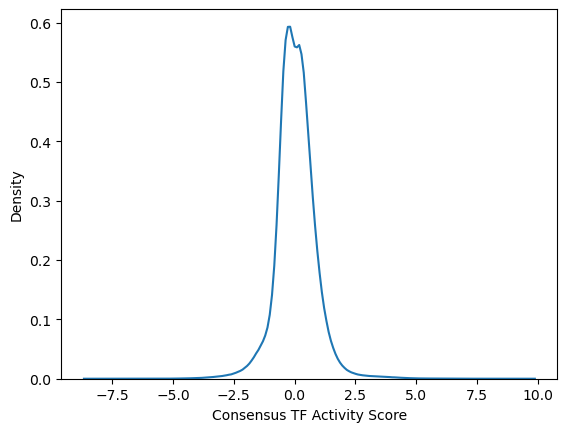

In [8]:
n_sample = int(1e4)
np.random.seed(seed)
obs_sub = np.random.choice(tf_adata.obs_names, 
                 size = n_sample, 
                 replace = False)

viz_dist = tf_adata[obs_sub, :].to_df().values.flatten()


fig, ax = plt.subplots()
sns.kdeplot(viz_dist, ax = ax)
ax.set_xlabel('Consensus TF Activity Score')
;
